## Ground Truth Simulation




In [17]:
import numpy as np
import random
np.random.seed(42)
sample_size = 100
potential_outcome_control = np.random.normal(0, 0.2, 100)
treat_positive = np.random.uniform(low=0, high=10, size=50)
treatment_effects = np.concatenate([treat_positive, -treat_positive])
#treatment_effects = np.zeros(sample_size) + np.random.normal(0.1,0.2,100)
np.random.shuffle(treatment_effects)
X = (treatment_effects > 0).astype(int)
potential_outcome_treatment = potential_outcome_control + treatment_effects

In [18]:
np.mean(potential_outcome_treatment) -  np.mean(potential_outcome_control)

np.float64(-1.3877787807814457e-17)

## Complete Randomized Experiments

In [19]:
def CRE(n1, sample_size):
  treatment_assignment = np.zeros(sample_size, dtype=int)
  treatment_assignment[:n1] = 1
  np.random.shuffle(treatment_assignment)


  observed_outcome = np.where(treatment_assignment == 1, potential_outcome_treatment, potential_outcome_control)
  return X, treatment_assignment, observed_outcome

## Estimator




In [20]:
import numpy as np
def DiM(n1, sample_size):
    _,treatment_assignment, observed_outcome = CRE(n1, sample_size)

    # Separate observed outcomes into treatment and control groups
    observed_outcome_treatment_group = observed_outcome[treatment_assignment == 1]
    observed_outcome_control_group = observed_outcome[treatment_assignment == 0]

    dim_estimate = np.mean(observed_outcome_treatment_group) - np.mean(observed_outcome_control_group)
    var_estimate = np.var(observed_outcome_treatment_group) / n1 + np.var(observed_outcome_control_group) / (sample_size-n1)
    return dim_estimate, var_estimate




In [5]:
DiM(30, 100)

(np.float64(0.03505874267686524), np.float64(0.0016782480367138746))

## Permutation_test



In [23]:
def permutation_test(treatment_assignment, observed_outcome, num_permutations=1000):
  observed_outcome_treatment_group = observed_outcome[treatment_assignment == 1]
  observed_outcome_control_group = observed_outcome[treatment_assignment == 0]
  permutation_assignment = treatment_assignment.copy()
  # Calculate the observed difference in variances
  div_estimate = np.mean(observed_outcome_treatment_group) - np.mean(observed_outcome_control_group)
  cnt = 0
  for _ in range(num_permutations):
      # Shuffle the combined data
      np.random.shuffle(permutation_assignment)

      # Divide into permuted treatment and control groups
      permuted_treatment_group =  observed_outcome[permutation_assignment == 1]

      permuted_control_group = observed_outcome[permutation_assignment == 0]

      # Calculate the difference in variances for this permutation
      permuted_estimate = np.mean(permuted_treatment_group) - np.mean(permuted_control_group)
      cnt = cnt + int(np.abs(permuted_estimate) >= np.abs(div_estimate))

  return cnt / num_permutations

In [29]:
pval=[]
dim_estimates = []
n1 = 30
for i in range(100):
  _,treatment_assignment, observed_outcome = CRE(n1, sample_size)
  pvalue = permutation_test(treatment_assignment, observed_outcome)
  pval.append(pvalue)


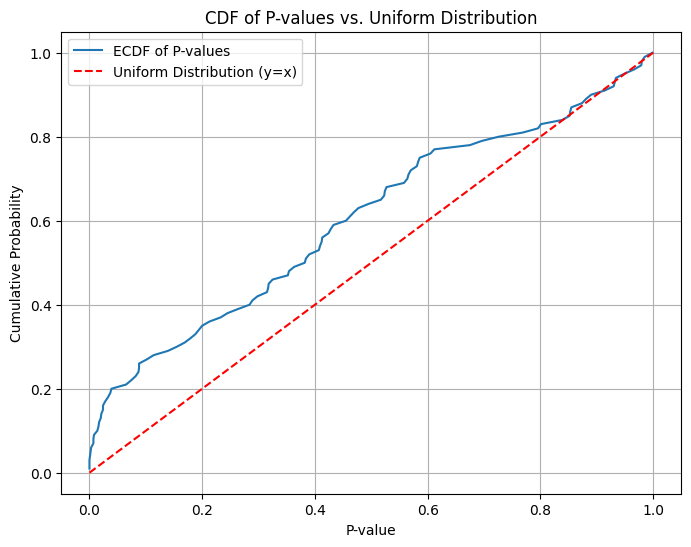

In [25]:
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# Convert pval list to a numpy array for sorting and ECDF calculation
pval_array = np.array(pval)

# Sort the p-values
pval_array.sort()

# Calculate the ECDF
ecdf = ECDF(pval_array)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(ecdf.x, ecdf.y, label='ECDF of P-values')

# Plot the y=x line for comparison (uniform distribution)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Uniform Distribution (y=x)')

# Add labels and title
plt.xlabel('P-value')
plt.ylabel('Cumulative Probability')
plt.title('CDF of P-values vs. Uniform Distribution')
plt.legend()
plt.grid(True)
plt.show()

## Neyman test

In [26]:
from scipy import stats


def neyman_test(treatment_assignment, observed_outcome):
  observed_outcome_treatment_group = observed_outcome[treatment_assignment == 1]
  observed_outcome_control_group = observed_outcome[treatment_assignment == 0]

  # Manual calculation for Z-test (assuming large samples or known variances for large-sample approximation)
  n1 = len(observed_outcome_treatment_group)
  n2 = len(observed_outcome_control_group)
  mean1 = np.mean(observed_outcome_treatment_group)
  mean2 = np.mean(observed_outcome_control_group)
  var1 = np.var(observed_outcome_treatment_group, ddof=1) # ddof=1 for sample variance
  var2 = np.var(observed_outcome_control_group, ddof=1) # ddof=1 for sample variance

  # Calculate Z-statistic
  z_statistic = (mean1 - mean2) / np.sqrt(var1/n1 + var2/n2)

  #print(var1/n1 + var2/n2)


  # Calculate p-value (two-sided test using standard normal distribution)
  p_value = 2 * stats.norm.sf(np.abs(z_statistic))

  return p_value

In [27]:
pval_neyman=[]
dim_estimates = []
n1 = 30
for i in range(1000):
  _,treatment_assignment, observed_outcome = CRE(n1, sample_size)
  pvalue = neyman_test(treatment_assignment, observed_outcome)
  pval_neyman.append(pvalue)


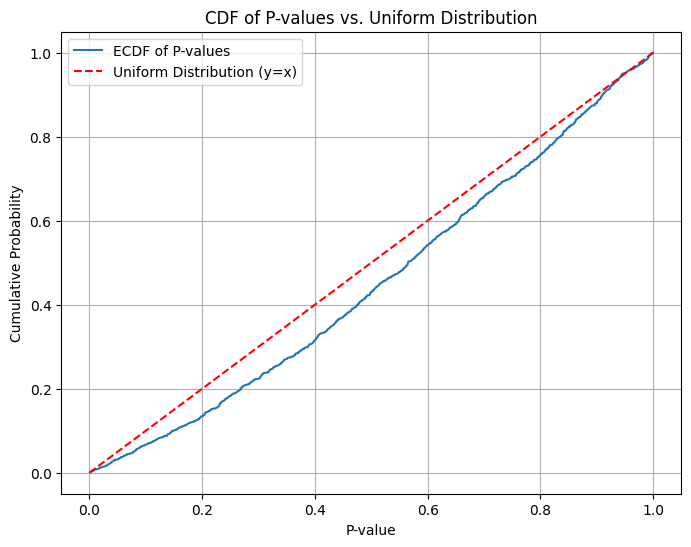

In [28]:
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# Convert pval list to a numpy array for sorting and ECDF calculation
pval_array = np.array(pval_neyman)

# Sort the p-values
pval_array.sort()

# Calculate the ECDF
ecdf = ECDF(pval_array)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(ecdf.x, ecdf.y, label='ECDF of P-values')

# Plot the y=x line for comparison (uniform distribution)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Uniform Distribution (y=x)')

# Add labels and title
plt.xlabel('P-value')
plt.ylabel('Cumulative Probability')
plt.title('CDF of P-values vs. Uniform Distribution')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
num_simulations = 1000
n1=30

dim_estimates = []
dim_var_estimates = []


dim_err = 0


for i in range(num_simulations):

    # Simulate and estimate using DiM
    dim_estimate, var_est = DiM(n1, sample_size)
    dim_estimates.append(dim_estimate)
    dim_var_estimates.append(var_est)
    dim_err += inference(dim_estimate, var_est)
print(f"Variance of DiM Estimate: {np.var(dim_estimates):.4f}, expectation of estimated DiM variance: {np.mean(dim_var_estimates):.4f}" )
print(f"DiM Error: {dim_err/num_simulations:.4f}")



Variance of DiM Estimate: 0.6536, expectation of estimated DiM variance: 0.9330
DiM Error: 0.0330


## Stratification

In [33]:
def post_stratification(n1, sample_size):

    feature, treatment_assignment, observed_outcome = CRE(n1, sample_size)

    # Filter data for feature == 0
    feature_0_indices = (feature == 0)
    ta_feature_0 = treatment_assignment[feature_0_indices]
    oo_feature_0 = observed_outcome[feature_0_indices]
    w0 = np.sum(feature_0_indices) / sample_size

    # Calculate DiM for feature == 0
    oo_feature_0_treatment = oo_feature_0[ta_feature_0 == 1]
    oo_feature_0_control = oo_feature_0[ta_feature_0 == 0]

    dim_feature_0 = np.mean(oo_feature_0_treatment) - np.mean(oo_feature_0_control)
    var_estimate_0 = np.var(oo_feature_0_treatment)/len(oo_feature_0_treatment) + np.var(oo_feature_0_control)/len(oo_feature_0_control)

    # Filter data for feature == 1
    feature_1_indices = (feature == 1)
    ta_feature_1 = treatment_assignment[feature_1_indices]
    oo_feature_1 = observed_outcome[feature_1_indices]
    w1 = np.sum(feature_1_indices) / sample_size

    # Calculate DiM for feature == 1
    oo_feature_1_treatment = oo_feature_1[ta_feature_1 == 1]
    oo_feature_1_control = oo_feature_1[ta_feature_1 == 0]

    dim_feature_1 = np.mean(oo_feature_1_treatment) - np.mean(oo_feature_1_control)
    var_estimate_1= np.var(oo_feature_1_treatment)/len(oo_feature_1_treatment) + np.var(oo_feature_1_control)/len(oo_feature_1_control)


    return w0 * dim_feature_0 + w1 * dim_feature_1, w0 ** 2 * var_estimate_0 + w1 ** 2 * var_estimate_1


## Regression Adjustment

In [36]:
import statsmodels.formula.api as smf
import pandas as pd

def simulate_and_estimate_regression_adjustment(n1, sample_size):
    feature, treatment_assignment, observed_outcome = CRE(n1, sample_size)

    # Create a DataFrame for regression
    data = pd.DataFrame({
        'observed_outcome': observed_outcome,
        'treatment_assignment': treatment_assignment,
        'feature': feature
    })

    # Fit a linear regression model: Y ~ W + X + W*X
    model = smf.ols('observed_outcome ~ treatment_assignment*feature', data=data).fit()

    # The ATE estimate is the coefficient of treatment_assignment plus the interaction term's coefficient multiplied by the mean of feature
    ra_estimate = model.params['treatment_assignment'] + model.params['treatment_assignment:feature'] * np.mean(feature)

    residuals = model.resid
    var_est = np.var(residuals[treatment_assignment == 1])/n1 + np.var(residuals[treatment_assignment == 0])/(sample_size-n1)
    #var_est = var_est +  np.var(feature) * model.params['treatment_assignment:feature']**2 / sample_size


    return ra_estimate, var_est

In [34]:
def inference(estimate, var):
  return int(np.abs(estimate)  / np.sqrt(var) >= 1.96)

In [38]:
num_simulations = 1000
n1=30

dim_estimates = []
dim_var_estimates = []
stra_estimates = []
stra_var_estimates = []
ra_estimates = []
ra_var_estimates =[]

dim_err = 0
ra_err = 0
stra_err = 0

for i in range(num_simulations):

    # Simulate and estimate using DiM
    dim_estimate, var_est = DiM(n1, sample_size)
    dim_estimates.append(dim_estimate)
    dim_var_estimates.append(var_est)
    dim_err += inference(dim_estimate, var_est)

    stra_estimate, var_est = post_stratification(n1, sample_size)
    stra_estimates.append(stra_estimate)
    stra_var_estimates.append(var_est)
    stra_err += inference(stra_estimate, var_est)





    ra_estimate, var_est = simulate_and_estimate_regression_adjustment(n1, sample_size)
    ra_estimates.append(ra_estimate)
    ra_var_estimates.append(var_est)
    ra_err += inference(ra_estimate, var_est)


print(f"Variance of DiM Estimate: {np.var(dim_estimates):.4f}, expectation of estimated DiM variance: {np.mean(dim_var_estimates):.4f}" )
print(f"DiM Error: {dim_err/num_simulations:.4f}")

print(f"Variance of Post-Stratification Estimate: {np.var(stra_estimates):.4f}, expectation of Post-Stratification variance: {np.mean(stra_var_estimates):.4f}" )
print(f"DiM Error: {stra_err/num_simulations:.4f}")

print(f"Variance of Reg Estimate: {np.var(ra_estimates):.4f}, expectation of estimated Rerg variance: {np.mean(ra_var_estimates):.4f}" )
print("Regression Adjustment error", ra_err / num_simulations)

Variance of DiM Estimate: 0.6480, expectation of estimated DiM variance: 0.9218
DiM Error: 0.0230
Variance of Post-Stratification Estimate: 0.1968, expectation of Post-Stratification variance: 0.2604
DiM Error: 0.0340
Variance of Reg Estimate: 0.1897, expectation of estimated Rerg variance: 0.2543
Regression Adjustment error 0.029


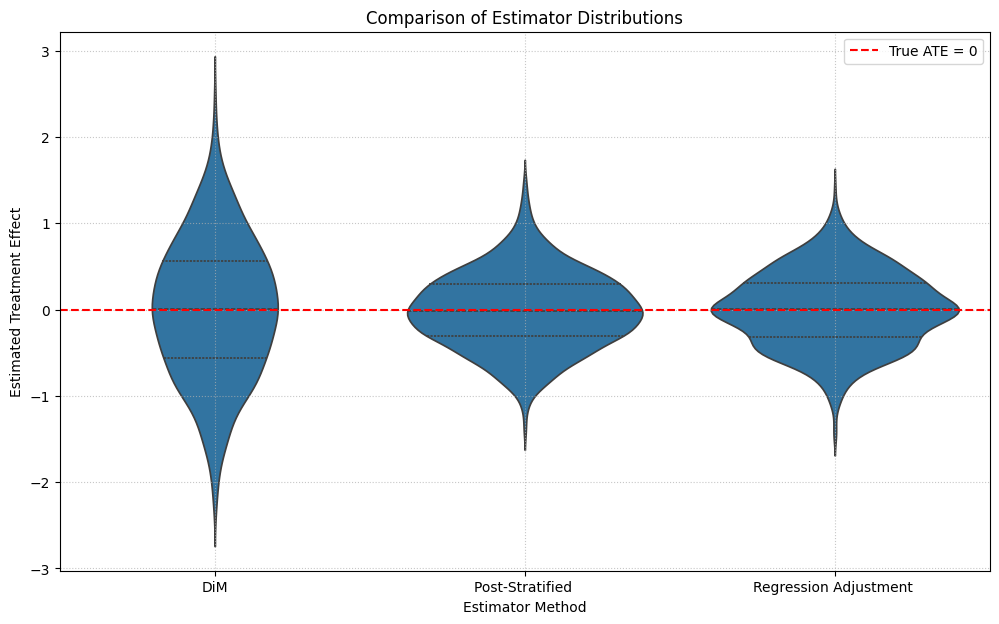

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine all estimates into a DataFrame for easier plotting
data = {
    'Estimator': ['DiM'] * len(dim_estimates) +
                 ['Post-Stratified '] * len(stra_estimates) +
                 ['Regression Adjustment '] * len(ra_estimates) ,

    'Estimate': dim_estimates +
                stra_estimates +
                ra_estimates

}
df = pd.DataFrame(data)

# Create the violin plot
plt.figure(figsize=(12, 7))
sns.violinplot(x='Estimator', y='Estimate', data=df, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=0, color='r', linestyle='--', label=f'True ATE = {0}')

# Add labels and title
plt.title('Comparison of Estimator Distributions')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()